# Predikcija rizika od kardiobaskularnih bolesti 
#### Nemanja Kostić 1753
#### Projekat iz predmeta "Veštačka inteligenicja u medicini"
#### Dataset: https://www.kaggle.com/datasets/bertnardomariouskono/cardiovascular-disease-risk-prediction-dataset


## Uvod
   
   Nad pomenutim datasetom iskorišćene su tehnike *ML*-a u cilju detektovanja i određivanje verovatnoće rizika oboljenja od kardiovaskularnih bolsti. Kardiovaskularne bolesti su oboljenja koja zahvataju srce i krvne sudove (arterije i vene). To su najčešći uzrok smrti u svetu, ali se mnoge mogu sprečiti zdravim načinom života i redovnim kontrolama. Konkretna tehnika koja je korišćena je binarna klasifikacija. U projektu je obrađeno više algoritama binarne klasifikacije koji će biti upoređeni. Rad se sastoji od preprocesiranja dataseta, primena algoritama i vizualizacija rezultata uz pomoć nekih validacionih metoda. Na kraju, rezultati će biti upoređeni sa *finetune*-ovanim algoritmima koji su se najbolje pokazali. 

### Dataset
- Patient_ID - Id pacijenta. Polje će biti ignorisano
- Age - Godina starosti
- Gender - Pol
- Height_cm	- Visina
- Weight_kg	- Težina
- BMI 	
- Systolic_BP 
- Diastolic_BP	
- Cholesterol_Total	
- Cholesterol_LDL	
- Cholesterol_HDL	
- Fasting_Blood_Sugar	
- Smoking_Status	
- Alcohol_Consumption	
- Physical_Activity_Level	
- Family_History	
- Stress_Level	
- Sleep_Hours	
- Heart_Disease_Risk

## Kod

### Library import

In [18]:
from sklearn.model_selection import cross_validate, train_test_split, KFold, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.covariance import EllipticEnvelope
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
from sklearn.calibration import cross_val_predict
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import make_scorer, recall_score
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.pipeline import Pipeline
import seaborn as sn
import pandas as pd
import numpy as np

sn.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)

### Helper functions

In [19]:
class ModelResult:
    """
    Stores results for one model.
    """
    def __init__(self, name, cv_metrics, y_pred_test=None, y_proba_test=None):
        self.name = name
        self.cv_metrics = cv_metrics          
        self.y_pred_test = y_pred_test        
        self.y_proba_test = y_proba_test      

results_list = []  # Rezultati svakog algoritma
tuned_parameters_results_list = [] # Rezultati algoritama posle fine-tuning-a hyper parametara

def evaluate_cv(pipeline, X_train, y_train, cv):
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring={
            'accuracy': 'accuracy',
            'macro_f1': 'f1_macro',
            'macro_recall': 'recall_macro'
        }
    )
    
    return {
        "accuracy": scores['test_accuracy'].mean(),
        "macro_f1": scores['test_macro_f1'].mean(),
        "macro_recall": scores['test_macro_recall'].mean()
    }

def train_and_predict(pipeline, X_train, y_train, X_test):
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)
    return y_pred, y_proba

def plot_confusion_matrix(y_true, y_pred, labels, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=labels)

    plt.figure(figsize=(8, 6))
    disp.plot(cmap="Blues", values_format="d")
    plt.title(title)
    plt.show()

def plot_roc(y_true, y_proba, classes, title):
    y_bin = label_binarize(y_true, classes=classes)

    if y_proba.ndim > 1:
        y_proba = y_proba[:, 1]

    fpr, tpr, _ = roc_curve(y_true, y_proba)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], '--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return roc_auc

def plot_cv_metrics(results_list, metrics=["accuracy","macro_f1","macro_recall"]):
    
    data = []
    for res in results_list:
        row = {"Algorithm": res.name}
        for m in metrics:
            row[m] = res.cv_metrics[m]
        data.append(row)

    df = pd.DataFrame(data)
    df_melted = df.melt(id_vars="Algorithm", var_name="Metric", value_name="Score")

    plt.figure(figsize=(10,6))
    ax = sn.barplot(data=df_melted, x="Algorithm", y="Score", hue="Metric")

    plt.ylim(0, 1.05)
    plt.title("CV Metrics Comparison")
    plt.xticks(rotation=45)
    plt.ylabel("Score")
    plt.legend(loc="lower right")

    # Smart automatic label placement
    for p in ax.patches:
        height = p.get_height()
        x = p.get_x() + p.get_width() / 2

        # Choose inside or above the bar
        if height > 0.15:
            va = "top"
            y = height - 0.02
            color = "white"
            weight = "bold"
        else:
            va = "bottom"
            y = height + 0.02
            color = "black"
            weight = "normal"

        ax.text(x, y, f"{height:.3f}", ha="center", va=va, color=color, fontsize=9, fontweight=weight)

    plt.tight_layout()
    plt.show()

def plot_feature_importance(model_pipeline, feature_names, top_n=None, title=None):
    
    if hasattr(model_pipeline, "named_steps"):
        steps = list(model_pipeline.named_steps.keys())
        model = model_pipeline.named_steps[steps[-1]]
        

        for step_name in steps[:-1]:
            step = model_pipeline.named_steps[step_name]
            if hasattr(step, 'get_feature_names_out'):
                feature_names = step.get_feature_names_out()
                break
    else:
        model = model_pipeline

    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
    elif hasattr(model, "coef_"):
        importances = np.mean(np.abs(model.coef_), axis=0) if model.coef_.ndim > 1 else np.abs(model.coef_)
    else:
        raise ValueError("Model does not have feature_importances_ or coef_")

    if len(feature_names) != len(importances):
        print(f"[Warning] feature_names length ({len(feature_names)}) != importances length ({len(importances)}). Using generic names.")
        feature_names = [f"feature_{i}" for i in range(len(importances))]

    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    }).sort_values(by="importance", ascending=False)

    if top_n:
        importance_df = importance_df.head(top_n)

    plt.figure()
    plt.barh(importance_df["feature"], importance_df["importance"])
    plt.gca().invert_yaxis()
    plt.title(title if title else "Feature Importance")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

    return importance_df

def plot_correlation_matrix(X, numerical_features, title="Feature Correlation Matrix"):
    df = pd.DataFrame(X, columns=X.columns if hasattr(X, 'columns') else numerical_features)
    corr = df[numerical_features].corr()  

    mask = np.triu(np.ones_like(corr, dtype=bool))

    plt.figure(figsize=(14, 10))
    sn.heatmap(
        corr,
        mask=mask,
        annot=True,
        fmt=".1f",
        cmap="coolwarm",
        center=0,
        square=True,
        linewidths=0.5,
        annot_kws={"size": 8}
    )
    plt.title(title, fontsize=14)
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.yticks(fontsize=9)
    plt.tight_layout()
    plt.show()

### Data import

In [20]:
dataframe = pd.read_csv('healthcare_synthetic_data.csv')

dataframe.head(15)

,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Family_History,Stress_Level,Sleep_Hours,Heart_Disease_Risk
0,PID-00001,60,0,146.9,51.3,23.8,140,89,217,151,52,83,0,1,3,0,1,8,0
1,PID-00002,53,0,161.8,76.6,29.3,128,81,203,119,38,116,0,0,1,0,7,9,0
2,PID-00003,62,1,174.7,92.4,30.3,141,100,173,124,45,90,0,0,0,0,1,7,1
3,PID-00004,73,1,173.3,68.9,22.9,136,96,193,117,45,81,0,0,1,0,2,7,1
4,PID-00005,52,1,178.6,79.8,25.0,122,80,236,153,41,79,0,1,2,0,2,6,0
5,PID-00006,52,0,159.6,60.3,23.7,134,92,225,155,48,103,0,0,1,1,4,8,0
6,PID-00007,73,0,158.2,62.7,25.0,149,98,260,166,46,103,0,0,2,0,6,8,0
7,PID-00008,64,0,144.5,72.0,34.5,129,90,237,160,44,108,0,1,2,0,6,7,0
8,PID-00009,49,0,168.7,80.2,28.2,139,91,227,138,37,90,1,0,2,0,3,5,1
9,PID-00010,61,1,176.8,113.6,36.3,131,91,206,139,38,103,0,0,2,0,10,8,0


In [21]:
print(dataframe.count)

<bound method DataFrame.count of       Patient_ID  Age  Gender  Height_cm  Weight_kg   BMI  Systolic_BP  \
0      PID-00001   60       0      146.9       51.3  23.8          140   
1      PID-00002   53       0      161.8       76.6  29.3          128   
2      PID-00003   62       1      174.7       92.4  30.3          141   
3      PID-00004   73       1      173.3       68.9  22.9          136   
4      PID-00005   52       1      178.6       79.8  25.0          122   
...          ...  ...     ...        ...        ...   ...          ...   
14995  PID-14996   44       1      166.9       81.8  29.4          135   
14996  PID-14997   69       0      154.0       61.7  26.0          124   
14997  PID-14998   70       1      178.5       88.6  27.8          129   
14998  PID-14999   44       0      157.3       60.5  24.5          122   
14999  PID-15000   53       1      170.1       72.7  25.1          150   

       Diastolic_BP  Cholesterol_Total  Cholesterol_LDL  Cholesterol_HDL  \
0 

### Data preprocessing 

In [22]:
# Brisanje podataka sa null vrednostima, augmentacija u ovom datasetu nije potrebna
dataframe.dropna(inplace=True) 

# ID pacijenta nam nije potreban 
dataframe = dataframe.drop("Patient_ID", axis=1)

#### Outlier detection

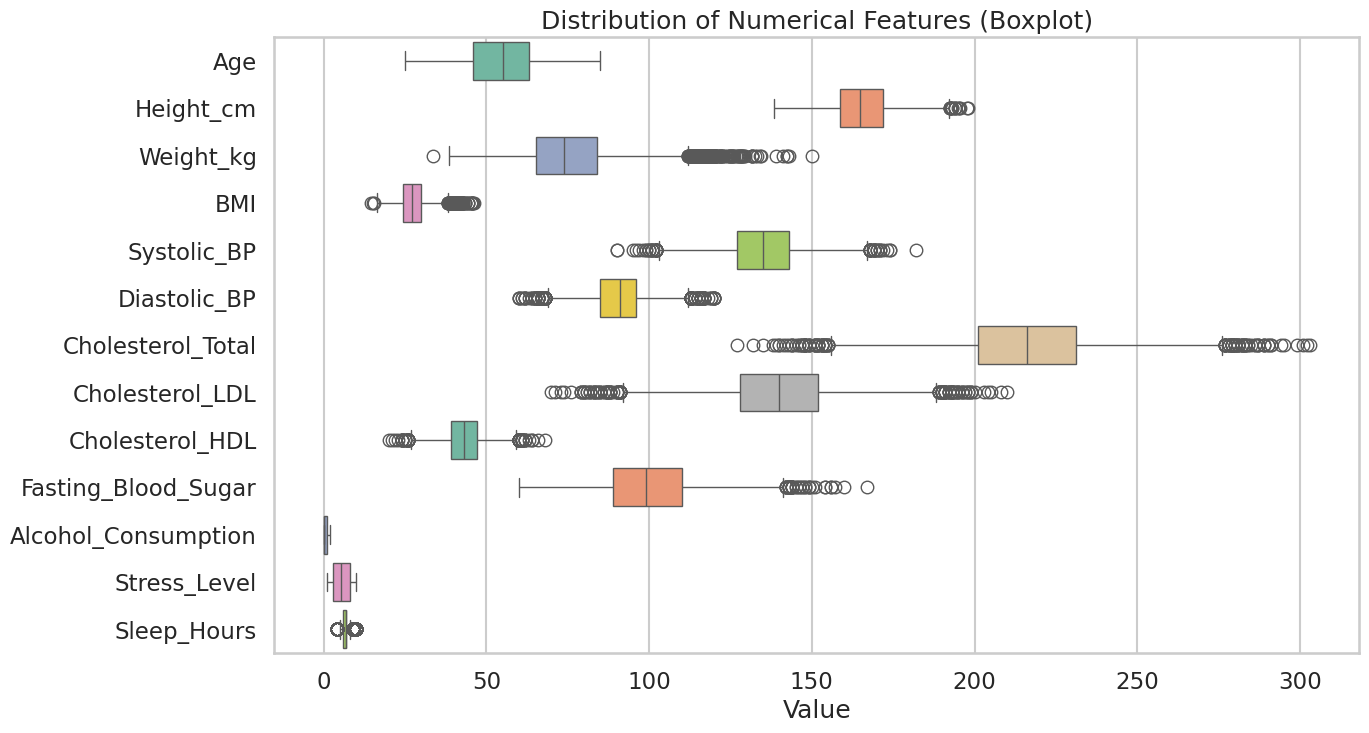

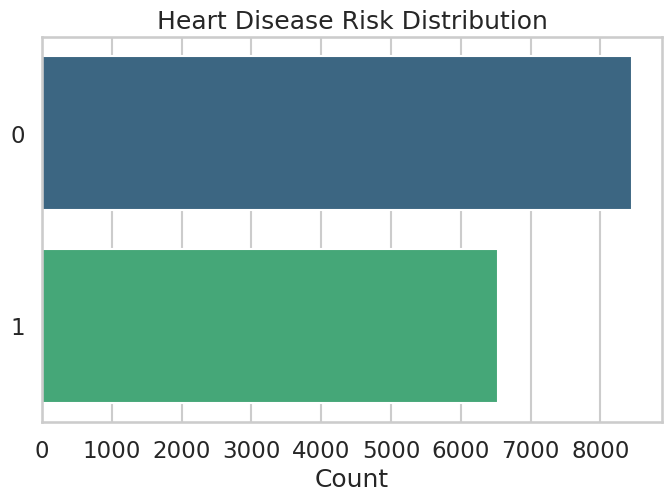

In [23]:
categorical = ['Gender', "Smoking_Status", "Physical_Activity_Level", "Family_History", "Heart_Disease_Risk"]
numerical = ['Age',	'Height_cm', 'Weight_kg', 'BMI', 'Systolic_BP',	'Diastolic_BP',	'Cholesterol_Total', 'Cholesterol_LDL', 'Cholesterol_HDL','Fasting_Blood_Sugar', 'Alcohol_Consumption', 'Stress_Level',	'Sleep_Hours']
feature_names = categorical + numerical

plt.figure(figsize=(14, 8))
sn.boxplot(data=dataframe[numerical], orient="h", palette="Set2")
plt.title("Distribution of Numerical Features (Boxplot)")
plt.xlabel("Value")
plt.show()


plt.figure(figsize=(8, 5))
sn.countplot(
    y='Heart_Disease_Risk',
    hue='Heart_Disease_Risk',
    data=dataframe,
    order=dataframe['Heart_Disease_Risk'].value_counts().index,
    palette='viridis',
    legend=False
)
plt.title("Heart Disease Risk Distribution")
plt.xlabel("Count")
plt.ylabel("")
plt.show()

#### Outlier removal

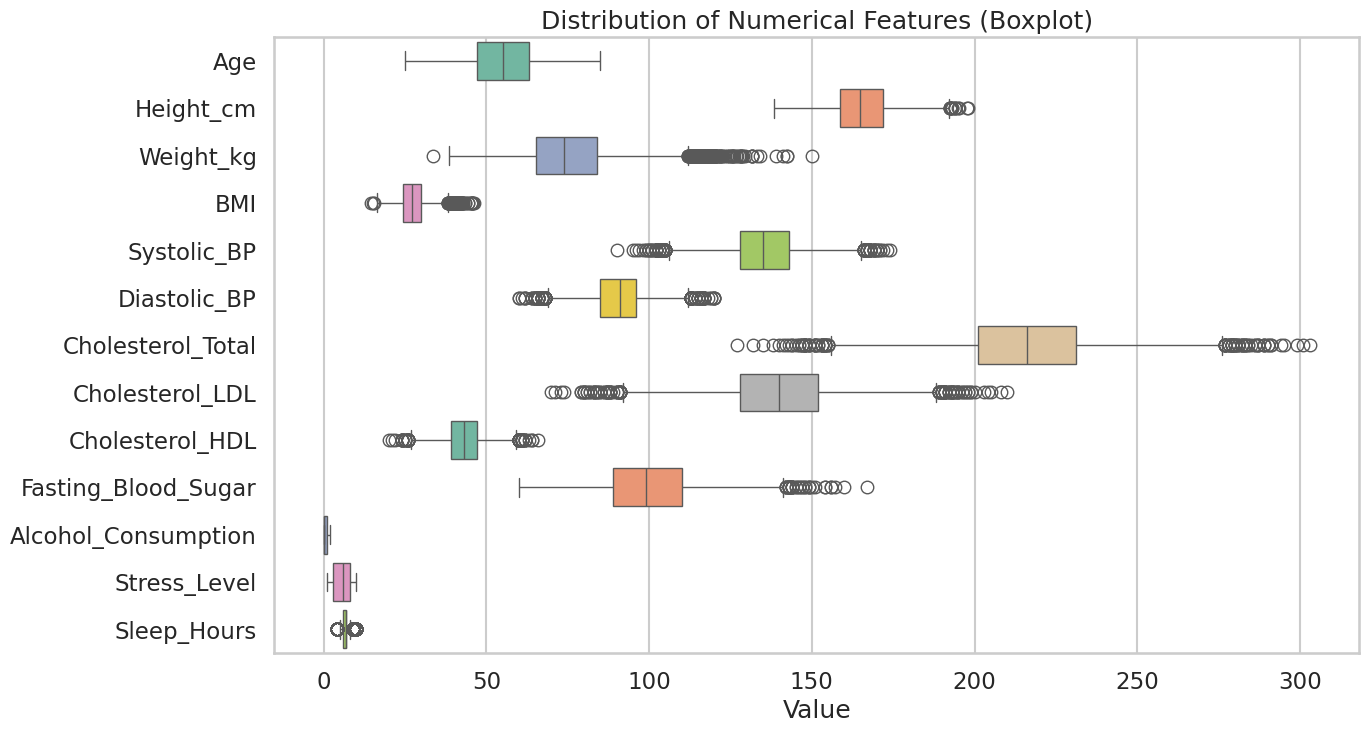

Removed 75 outliers (0.50%)


In [24]:
X = dataframe[numerical]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

iso = IsolationForest(
    n_estimators=300,
    contamination=0.005,
    random_state=42
)

outliers = iso.fit_predict(X_scaled)
dataframe = dataframe[outliers == 1]

plt.figure(figsize=(14, 8))
sn.boxplot(data=dataframe[numerical], orient="h", palette="Set2")
plt.title("Distribution of Numerical Features (Boxplot)")
plt.xlabel("Value")
plt.show()

print(f"Removed {np.sum(outliers==-1)} outliers ({np.mean(outliers==-1)*100:.2f}%)")

#### Train-Test split, izdvojićemo test podskup za finalno testiranje modela na kraju

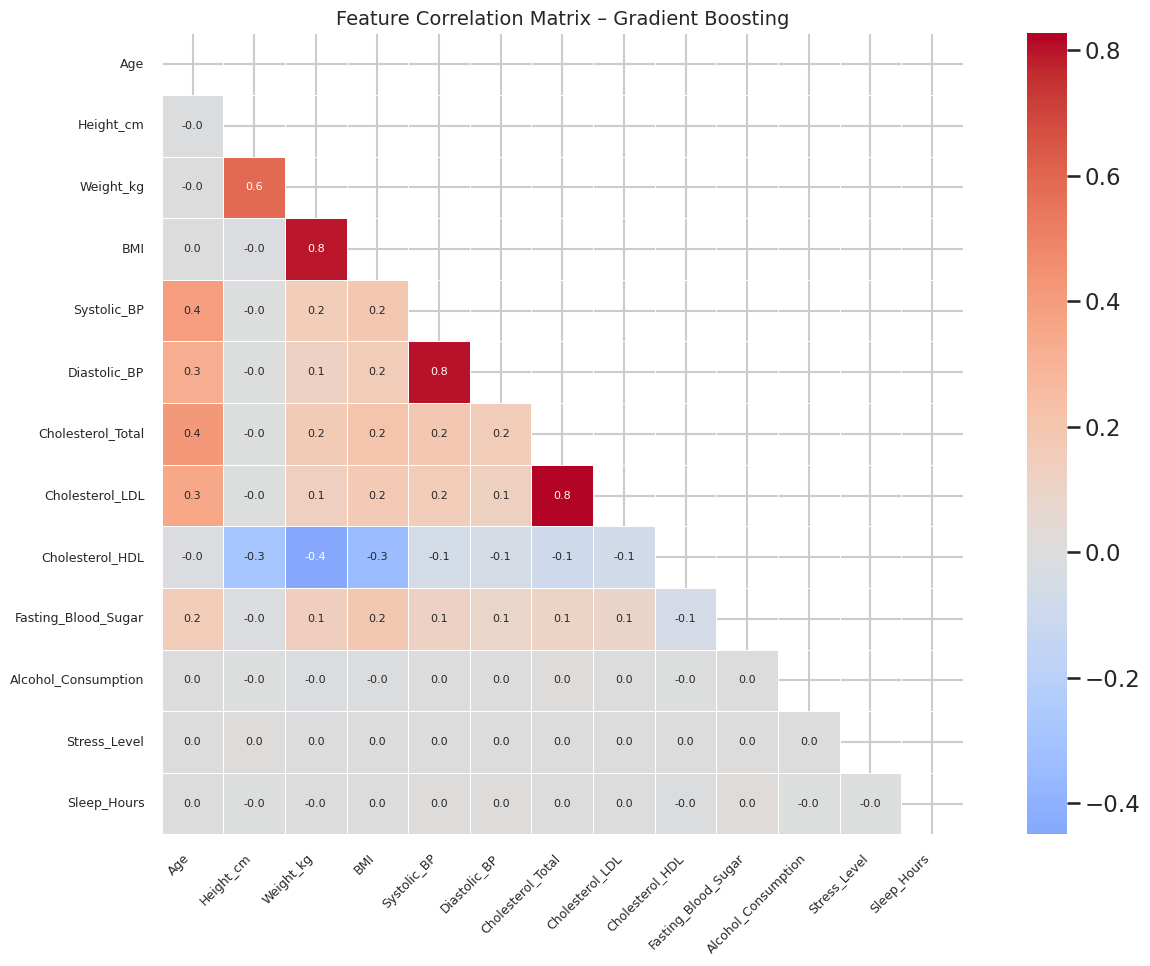

In [25]:
X = dataframe.drop('Heart_Disease_Risk', axis=1)
y = dataframe['Heart_Disease_Risk']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

plot_correlation_matrix(dataframe, numerical, "Feature Correlation Matrix – Gradient Boosting")

### Testiranje različitih algoritama multiklasne klasifikacije

#### RandomForestClassifier

Random Forest (CV mean):
Accuracy       : 0.721
Macro_f1       : 0.712
Macro_recall   : 0.710


<Figure size 800x600 with 0 Axes>

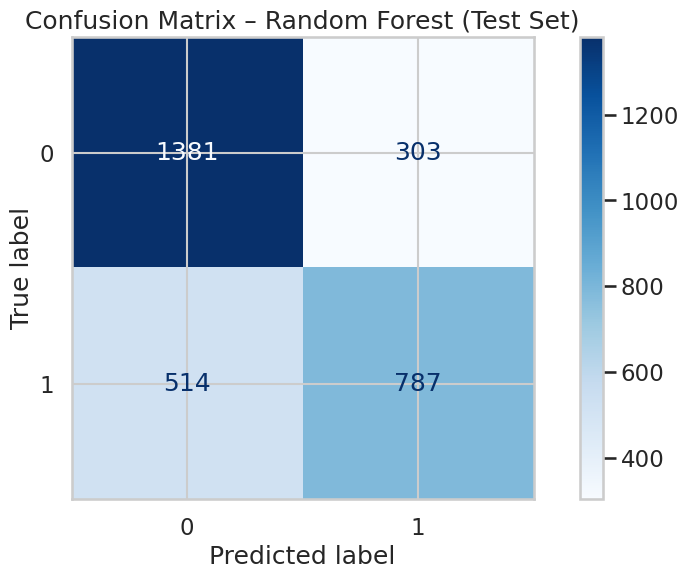

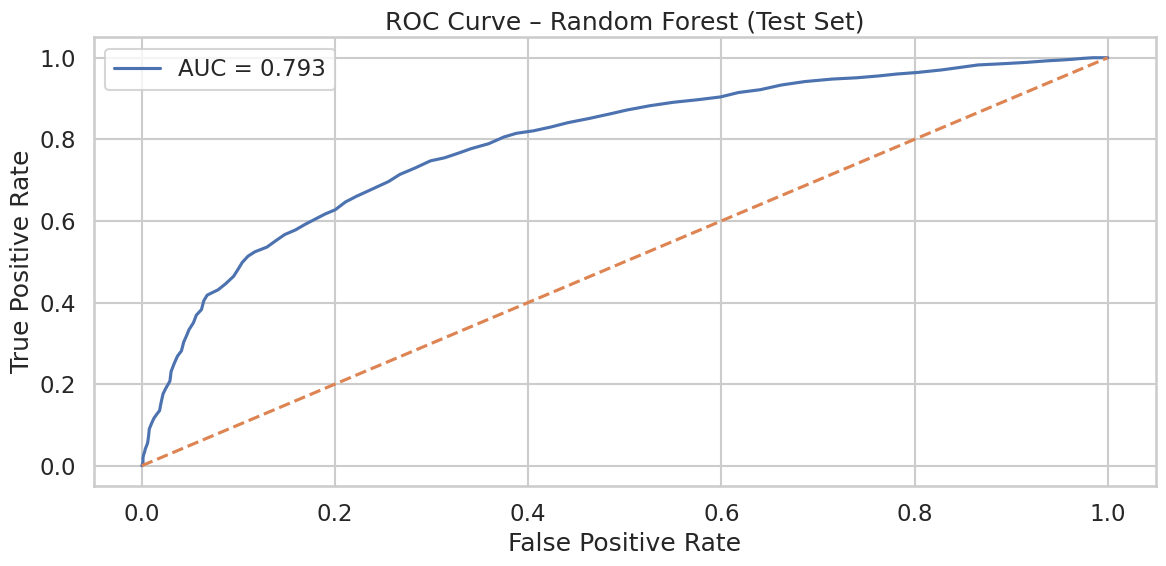

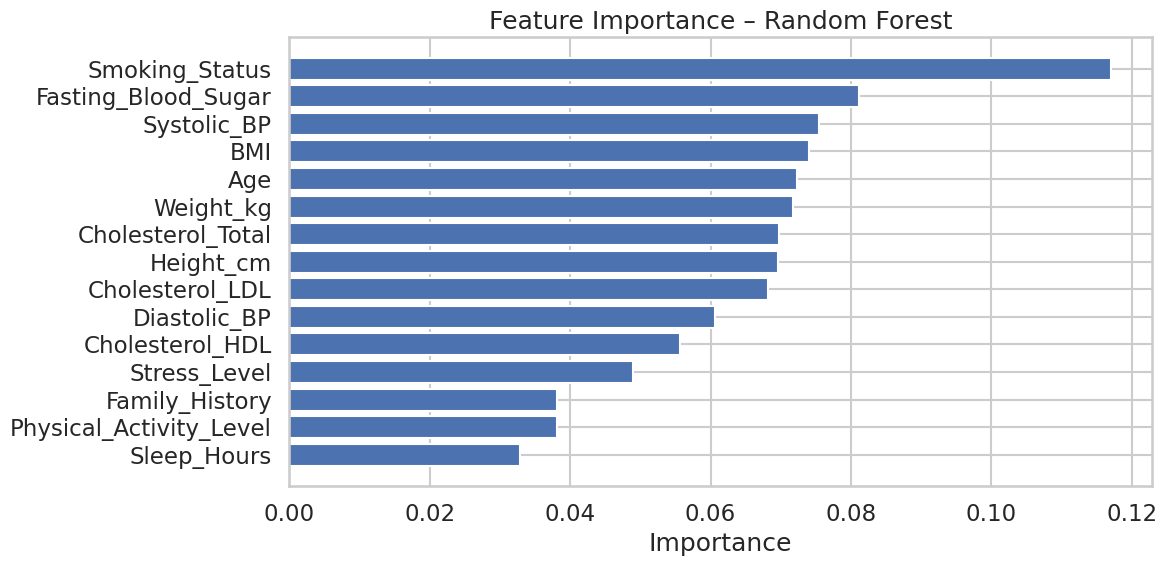

In [26]:
pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier())
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = evaluate_cv(pipeline_rf, X_train, y_train, cv)

print("Random Forest (CV mean):")
for k, v in cv_results.items():
    print(f"{k.capitalize():15}: {v:.3f}")

y_pred_test, y_proba_test = train_and_predict(
    pipeline_rf, X_train, y_train, X_test
)

classes = np.unique(y_train)

plot_confusion_matrix(
    y_test, y_pred_test, classes,
    "Confusion Matrix – Random Forest (Test Set)"
)

plot_roc(
    y_test, y_proba_test, classes,
    "ROC Curve – Random Forest (Test Set)"
)

plot_feature_importance(pipeline_rf, feature_names, top_n=15, title="Feature Importance – Random Forest")

rf_result = ModelResult(
    name="Random Forest",
    cv_metrics=cv_results,
    y_pred_test=y_pred_test,
    y_proba_test=y_proba_test
)

results_list.append(rf_result)


Random Forest (CV mean):
Accuracy       : 0.721
Macro_f1       : 0.712
Macro_recall   : 0.710


<Figure size 800x600 with 0 Axes>

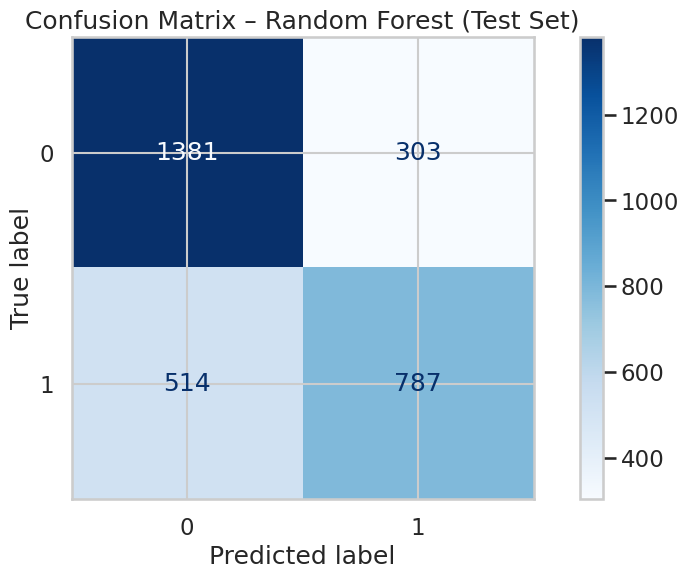

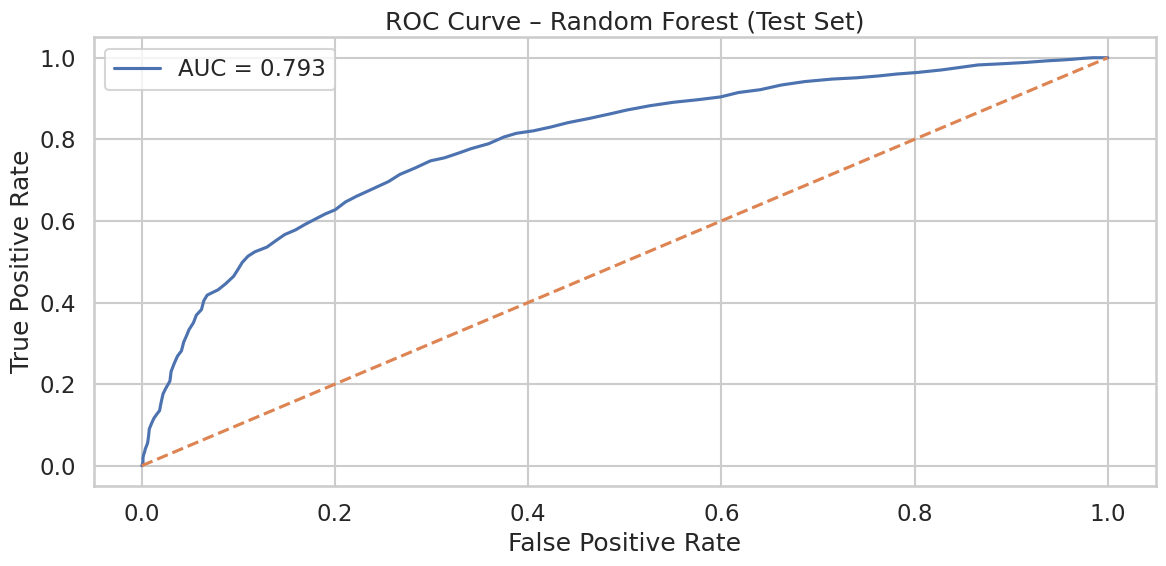

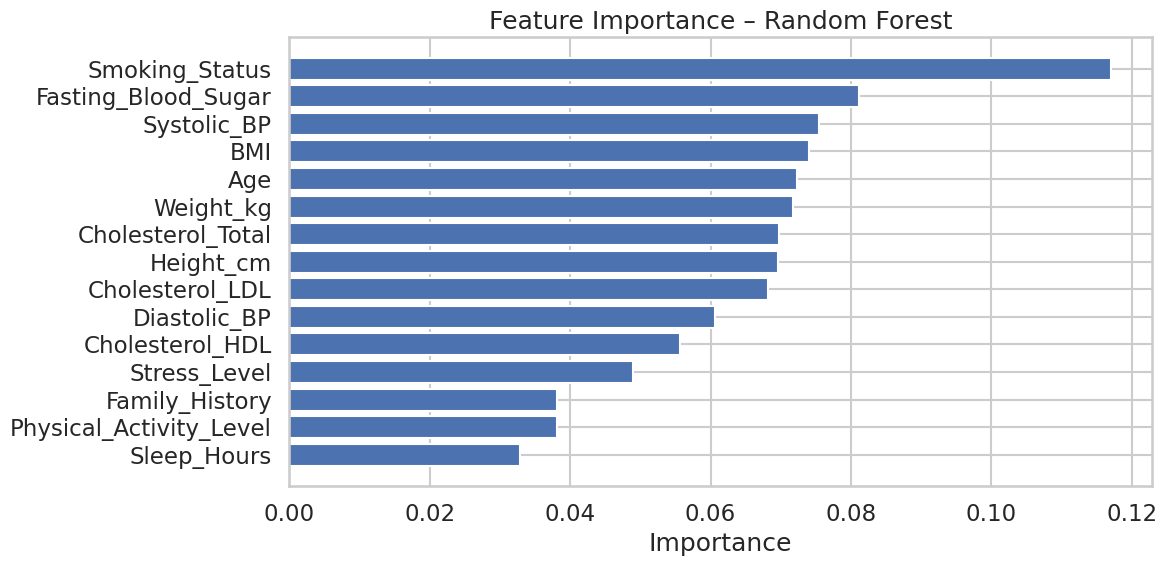

In [ ]:
pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier())
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = evaluate_cv(pipeline_rf, X_train, y_train, cv)

print("Random Forest (CV mean):")
for k, v in cv_results.items():
    print(f"{k.capitalize():15}: {v:.3f}")

y_pred_test, y_proba_test = train_and_predict(
    pipeline_rf, X_train, y_train, X_test
)

classes = np.unique(y_train)

plot_confusion_matrix(
    y_test, y_pred_test, classes,
    "Confusion Matrix – Random Forest (Test Set)"
)

plot_roc(
    y_test, y_proba_test, classes,
    "ROC Curve – Random Forest (Test Set)"
)

plot_feature_importance(pipeline_rf, feature_names, top_n=15, title="Feature Importance – Random Forest")

rf_result = ModelResult(
    name="Random Forest",
    cv_metrics=cv_results,
    y_pred_test=y_pred_test,
    y_proba_test=y_proba_test
)

results_list.append(rf_result)


#### Naive Bayes

Naive Bayes (CV mean):
Accuracy       : 0.714
Macro_f1       : 0.709
Macro_recall   : 0.708


<Figure size 800x600 with 0 Axes>

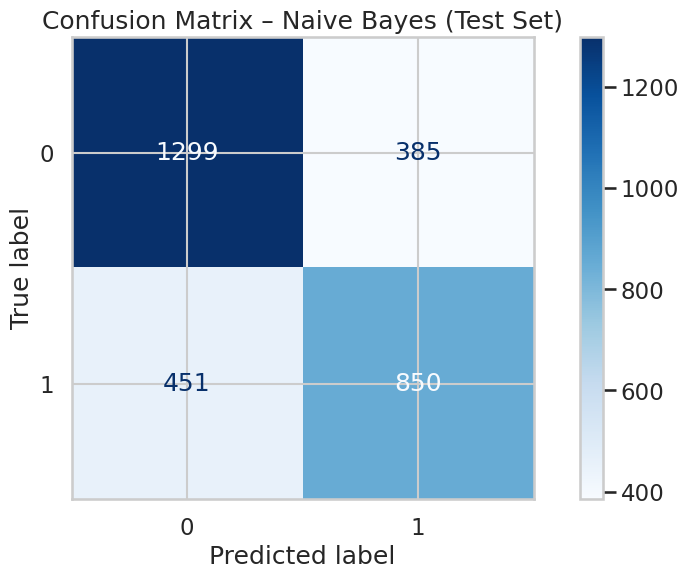

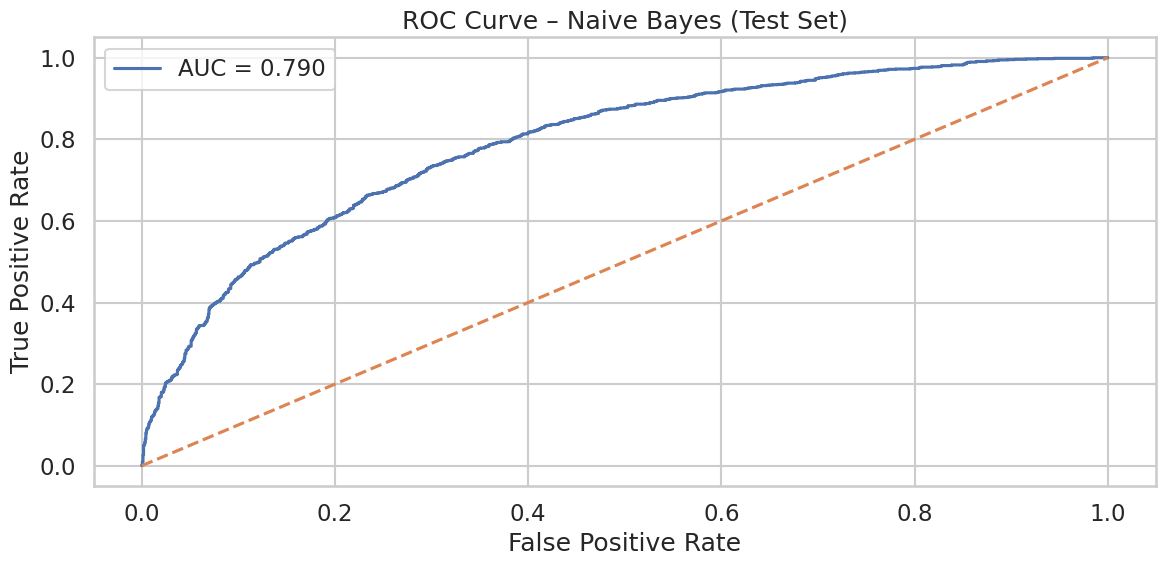

In [27]:
pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('model', GaussianNB())
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = evaluate_cv(pipeline_rf, X_train, y_train, cv)

print("Naive Bayes (CV mean):")
for k, v in cv_results.items():
    print(f"{k.capitalize():15}: {v:.3f}")

y_pred_test, y_proba_test = train_and_predict(
    pipeline_rf, X_train, y_train, X_test
)

classes = np.unique(y_train)

plot_confusion_matrix(
    y_test, y_pred_test, classes,
    "Confusion Matrix – Naive Bayes (Test Set)"
)

plot_roc(
    y_test, y_proba_test, classes,
    "ROC Curve – Naive Bayes (Test Set)"
)


rf_result = ModelResult(
    name="Naive Bayes",
    cv_metrics=cv_results,
    y_pred_test=y_pred_test,
    y_proba_test=y_proba_test
)

results_list.append(rf_result)


#### K-Nearest Neighbors

K-Nearest Neighbors (CV mean):
Accuracy       : 0.682
Macro_f1       : 0.674
Macro_recall   : 0.673


<Figure size 800x600 with 0 Axes>

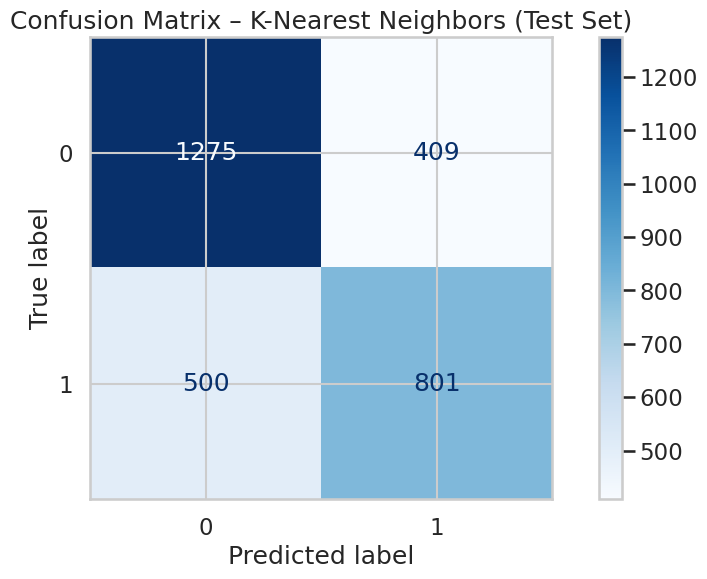

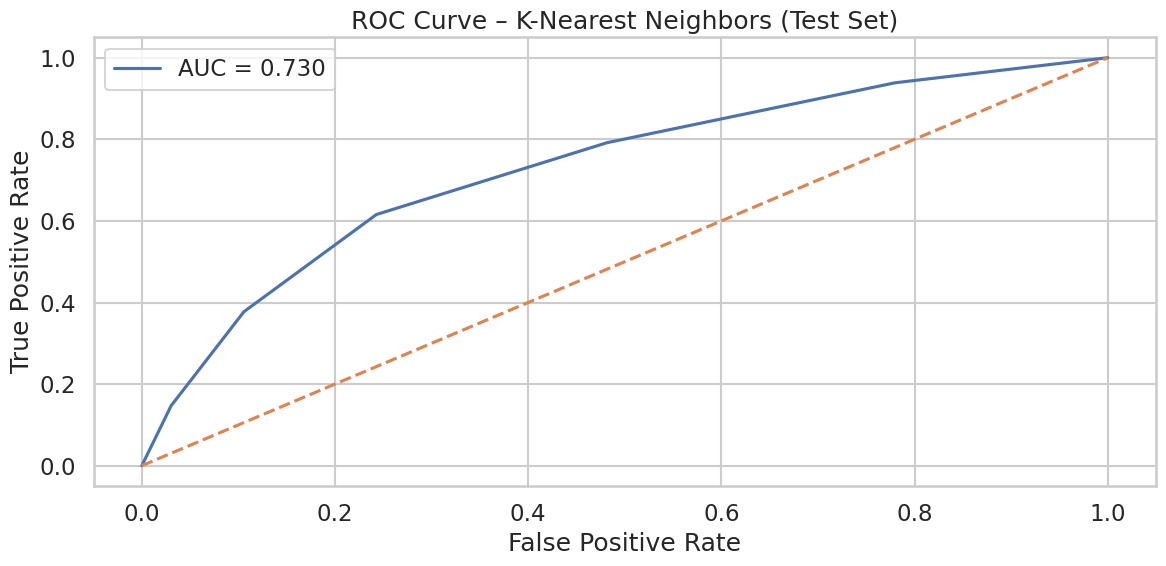

In [28]:
pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier())
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = evaluate_cv(pipeline_rf, X_train, y_train, cv)

print("K-Nearest Neighbors (CV mean):")
for k, v in cv_results.items():
    print(f"{k.capitalize():15}: {v:.3f}")

y_pred_test, y_proba_test = train_and_predict(
    pipeline_rf, X_train, y_train, X_test
)

classes = np.unique(y_train)

plot_confusion_matrix(
    y_test, y_pred_test, classes,
    "Confusion Matrix – K-Nearest Neighbors (Test Set)"
)

plot_roc(
    y_test, y_proba_test, classes,
    "ROC Curve – K-Nearest Neighbors (Test Set)"
)


rf_result = ModelResult(
    name="K-Nearest Neighbors",
    cv_metrics=cv_results,
    y_pred_test=y_pred_test,
    y_proba_test=y_proba_test
)

results_list.append(rf_result)


#### Gradient Boosting

Gradient Boosting (CV mean):
Accuracy       : 0.734
Macro_f1       : 0.725
Macro_recall   : 0.723


<Figure size 800x600 with 0 Axes>

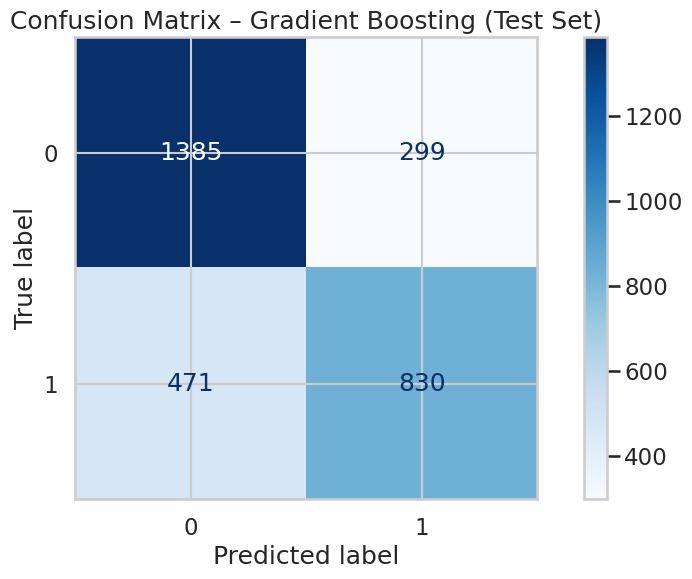

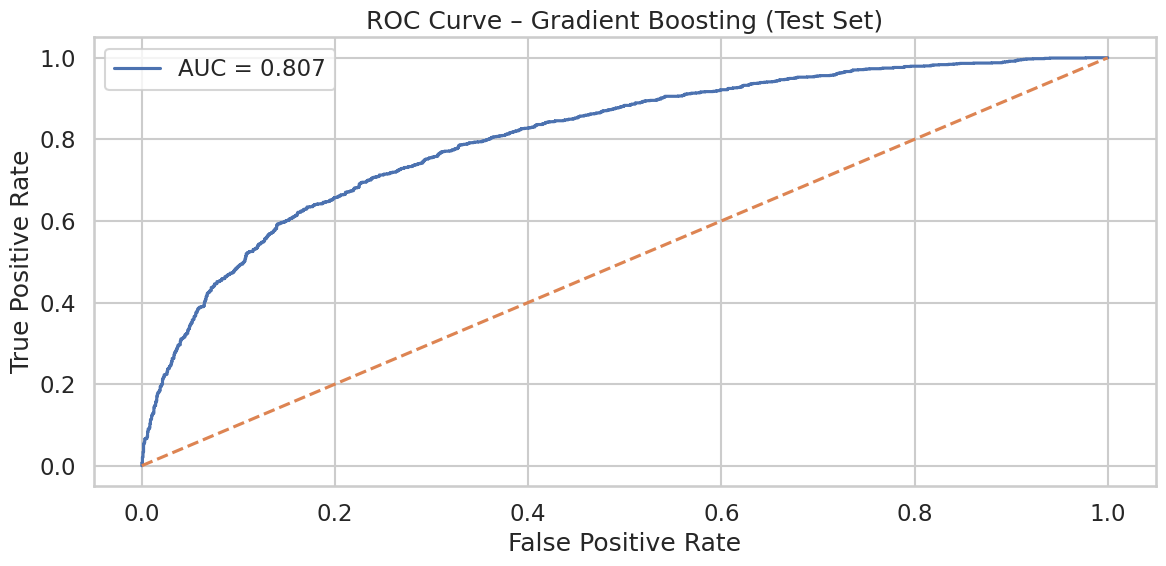

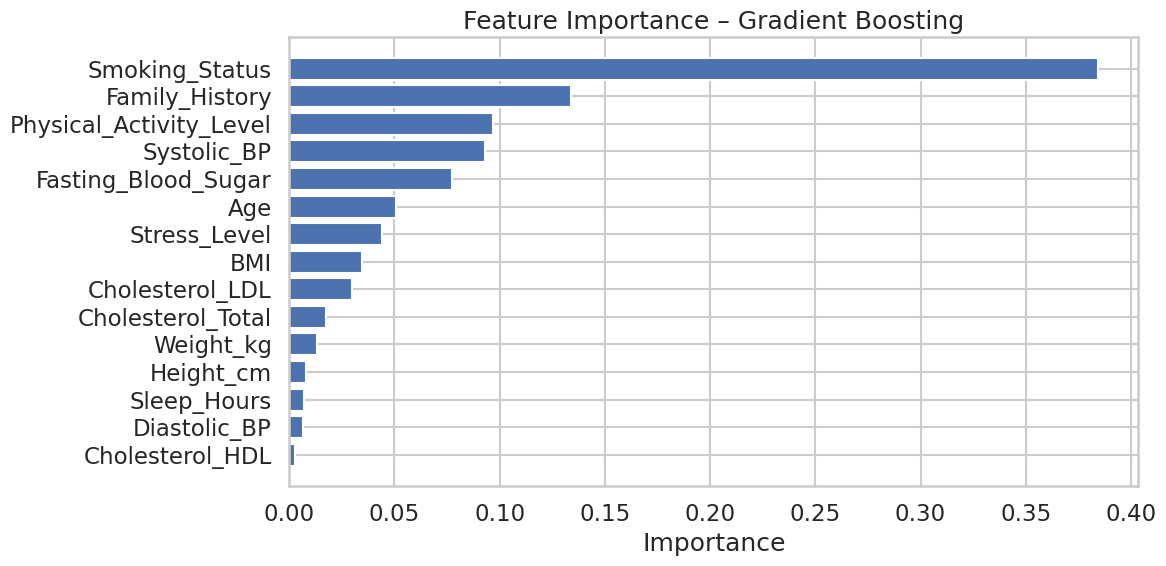

In [29]:
pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('model', GradientBoostingClassifier())
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = evaluate_cv(pipeline_rf, X_train, y_train, cv)

print("Gradient Boosting (CV mean):")
for k, v in cv_results.items():
    print(f"{k.capitalize():15}: {v:.3f}")

y_pred_test, y_proba_test = train_and_predict(
    pipeline_rf, X_train, y_train, X_test
)

classes = np.unique(y_train)

plot_confusion_matrix(
    y_test, y_pred_test, classes,
    "Confusion Matrix – Gradient Boosting (Test Set)"
)

plot_roc(
    y_test, y_proba_test, classes,
    "ROC Curve – Gradient Boosting (Test Set)"
)

plot_feature_importance(pipeline_rf, feature_names, top_n=15, title="Feature Importance – Gradient Boosting")

rf_result = ModelResult(
    name="Gradient Boosting",
    cv_metrics=cv_results,
    y_pred_test=y_pred_test,
    y_proba_test=y_proba_test
)

results_list.append(rf_result)


#### Logistic Regression

Logistic Regression (CV mean):
Accuracy       : 0.736
Macro_f1       : 0.727
Macro_recall   : 0.725


<Figure size 800x600 with 0 Axes>

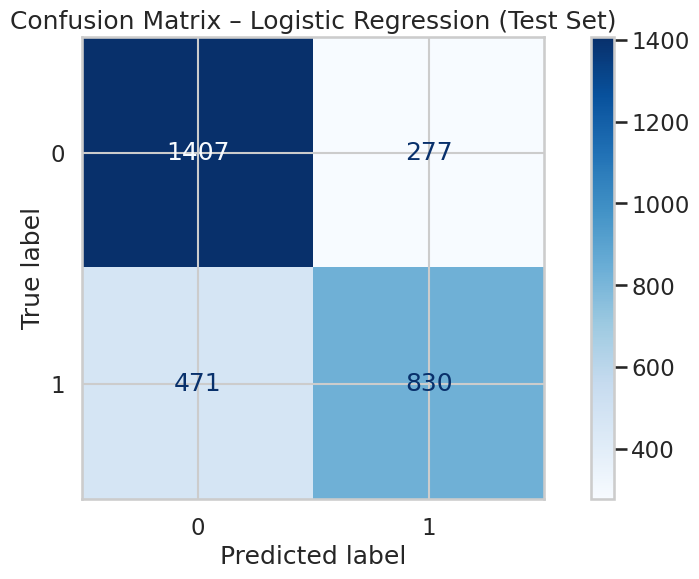

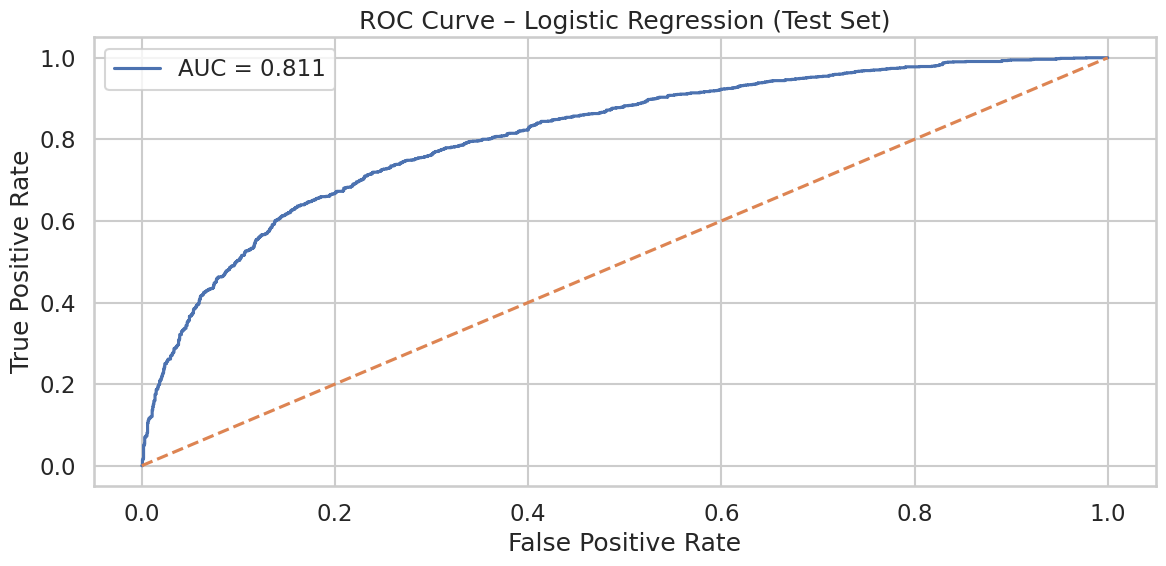

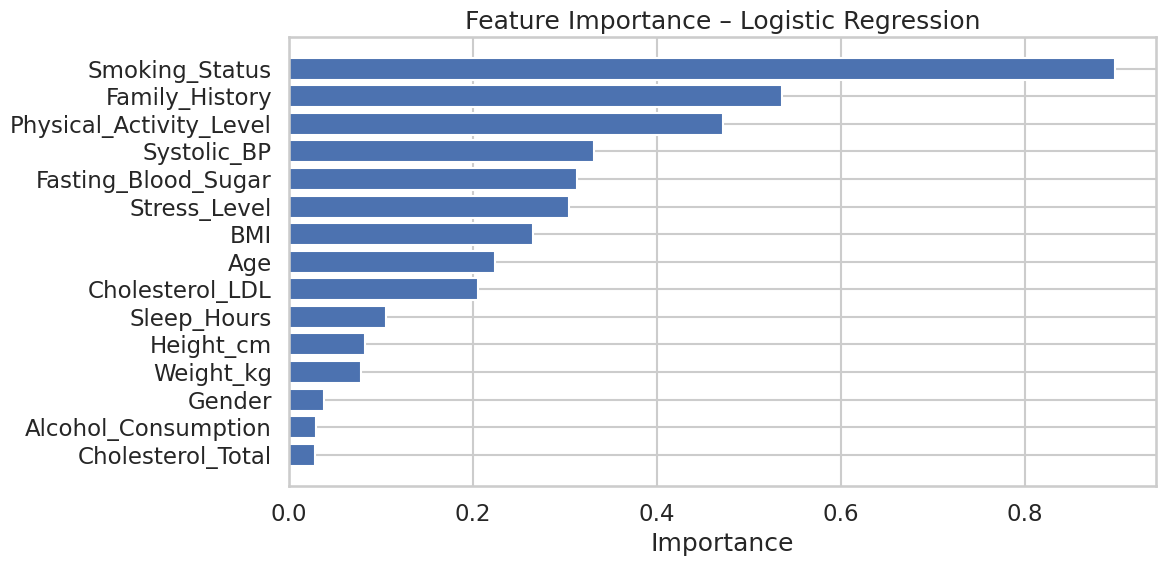

In [30]:
pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = evaluate_cv(pipeline_rf, X_train, y_train, cv)

print("Logistic Regression (CV mean):")
for k, v in cv_results.items():
    print(f"{k.capitalize():15}: {v:.3f}")

y_pred_test, y_proba_test = train_and_predict(
    pipeline_rf, X_train, y_train, X_test
)

classes = np.unique(y_train)

plot_confusion_matrix(
    y_test, y_pred_test, classes,
    "Confusion Matrix – Logistic Regression (Test Set)"
)

plot_roc(
    y_test, y_proba_test, classes,
    "ROC Curve – Logistic Regression (Test Set)"
)

plot_feature_importance(pipeline_rf, feature_names, top_n=15, title="Feature Importance – Logistic Regression")

rf_result = ModelResult(
    name="Logistic Regression",
    cv_metrics=cv_results,
    y_pred_test=y_pred_test,
    y_proba_test=y_proba_test
)

results_list.append(rf_result)


### Model comparison

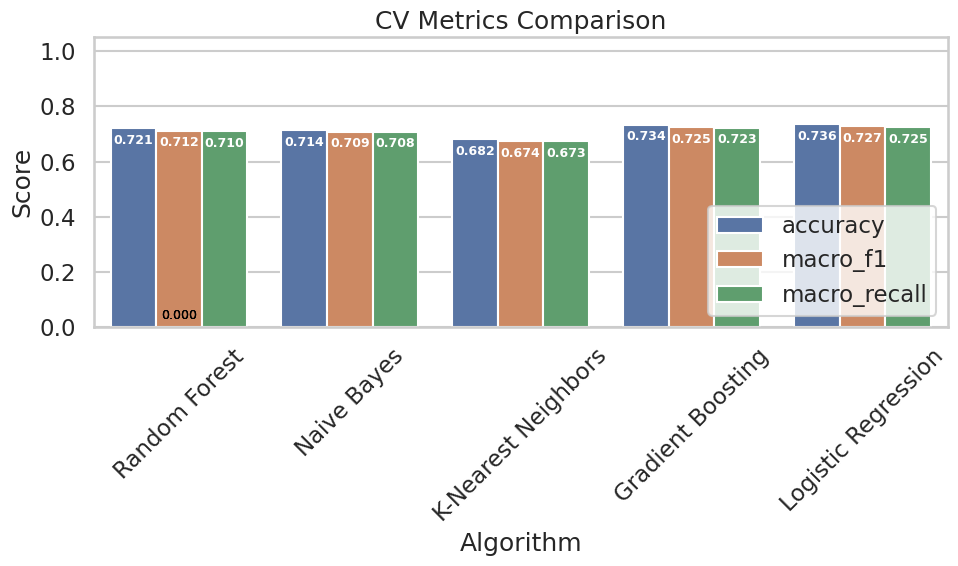

In [31]:
plot_cv_metrics(results_list)

### Hyperparameters tuning

Zbog dobrih performansi, biramo *Random Forest* i *Gradient Boosting*.

#### Logistic regresion Hyperparameters tuning

In [32]:
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(random_state=42, max_iter=1000))
])

param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l1', 'l2'],
    'model__solver': ['liblinear', 'saga'],
    'model__class_weight': [None, 'balanced']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = make_scorer(recall_score, average='macro')

grid_search_lr = GridSearchCV(
    estimator=pipeline_lr,
    param_grid=param_grid,
    scoring=scoring,
    cv=cv,
    n_jobs=-1,
    verbose=2
)

grid_search_lr.fit(X_train, y_train)

print("Best parameters found:", grid_search_lr.best_params_)
print("Best CV score:", grid_search_lr.best_score_)


Fitting 5 folds for each of 40 candidates, totalling 200 fits
[CV] END model__C=0.01, model__class_weight=None, model__penalty=l1, model__solver=liblinear; total time=   0.1s
[CV] END model__C=0.01, model__class_weight=None, model__penalty=l1, model__solver=liblinear; total time=   0.1s
[CV] END model__C=0.01, model__class_weight=None, model__penalty=l1, model__solver=liblinear; total time=   0.1s
[CV] END model__C=0.01, model__class_weight=None, model__penalty=l1, model__solver=liblinear; total time=   0.1s
[CV] END model__C=0.01, model__class_weight=None, model__penalty=l1, model__solver=saga; total time=   0.1s
[CV] END model__C=0.01, model__class_weight=None, model__penalty=l1, model__solver=liblinear; total time=   0.1s
[CV] END model__C=0.01, model__class_weight=None, model__penalty=l1, model__solver=saga; total time=   0.1s
[CV] END model__C=0.01, model__class_weight=None, model__penalty=l2, model__solver=liblinear; total time=   0.1s
[CV] END model__C=0.01, model__class_weight=

<Figure size 800x600 with 0 Axes>

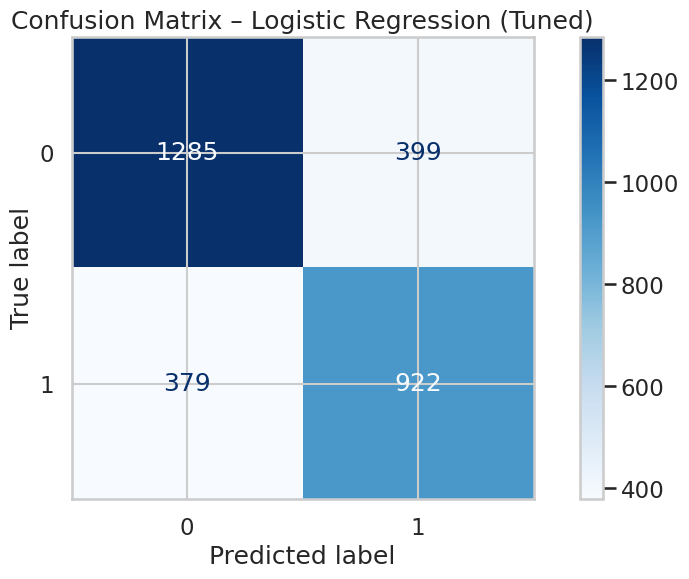

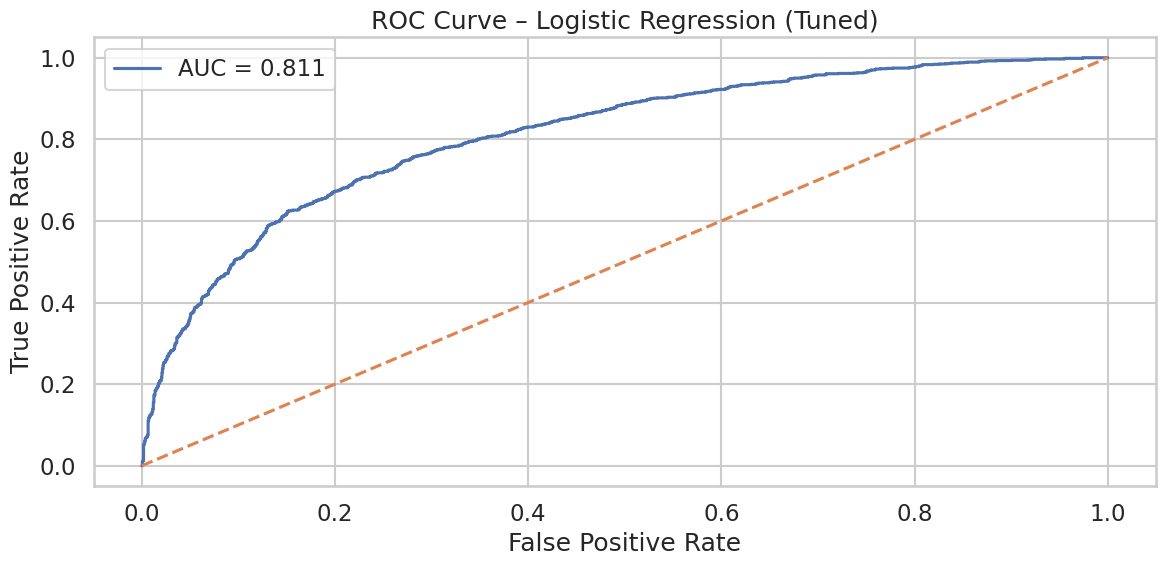

In [33]:
best_lr_model = grid_search_lr.best_estimator_

# Predict on test set
y_pred_test, y_proba_test = train_and_predict(best_lr_model, X_train, y_train, X_test)
classes = np.unique(y_train)

# Plot confusion matrix and ROC
plot_confusion_matrix(y_test, y_pred_test, classes, "Confusion Matrix – Logistic Regression (Tuned)")
plot_roc(y_test, y_proba_test, classes, "ROC Curve – Logistic Regression (Tuned)")

# Store results
lr_result = ModelResult(
    name="Logistic Regression (Tuned)",
    cv_metrics={
        'accuracy': grid_search_lr.cv_results_['mean_test_score'][grid_search_lr.best_index_],
        'macro_f1': grid_search_lr.cv_results_['mean_test_score'][grid_search_lr.best_index_],
        'macro_recall': grid_search_lr.cv_results_['mean_test_score'][grid_search_lr.best_index_]
    },
    y_pred_test=y_pred_test,
    y_proba_test=y_proba_test
)

tuned_parameters_results_list.append(lr_result)

#### Gradient Boosting Hiperparameters tuning

In [ ]:
pipeline_gb = Pipeline([
    ('scaler', StandardScaler()),          
    ('model', GradientBoostingClassifier(random_state=42))
])

param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__max_depth': [3, 5, 7],
    'model__subsample': [0.7, 1.0]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = make_scorer(recall_score, average='macro') 

grid_search = GridSearchCV(
    estimator=pipeline_gb,
    param_grid=param_grid,
    scoring=scoring,
    cv=cv,
    refit=True, 
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

best_gb_model = grid_search.best_estimator_

print("Best hyperparameters:", grid_search.best_params_)
print("Best CV macro F1 score:", grid_search.best_score_)

Fitting 5 folds for each of 54 candidates, totalling 270 fits
[CV] END model__learning_rate=0.01, model__max_depth=3, model__n_estimators=100, model__subsample=0.7; total time=   1.6s
[CV] END model__learning_rate=0.01, model__max_depth=3, model__n_estimators=100, model__subsample=0.7; total time=   1.7s
[CV] END model__learning_rate=0.01, model__max_depth=3, model__n_estimators=100, model__subsample=0.7; total time=   1.7s
[CV] END model__learning_rate=0.01, model__max_depth=3, model__n_estimators=100, model__subsample=0.7; total time=   1.8s
[CV] END model__learning_rate=0.01, model__max_depth=3, model__n_estimators=100, model__subsample=0.7; total time=   1.9s
[CV] END model__learning_rate=0.01, model__max_depth=3, model__n_estimators=100, model__subsample=1.0; total time=   2.1s
[CV] END model__learning_rate=0.01, model__max_depth=3, model__n_estimators=100, model__subsample=1.0; total time=   2.2s
[CV] END model__learning_rate=0.01, model__max_depth=3, model__n_estimators=100, mod

<Figure size 800x600 with 0 Axes>

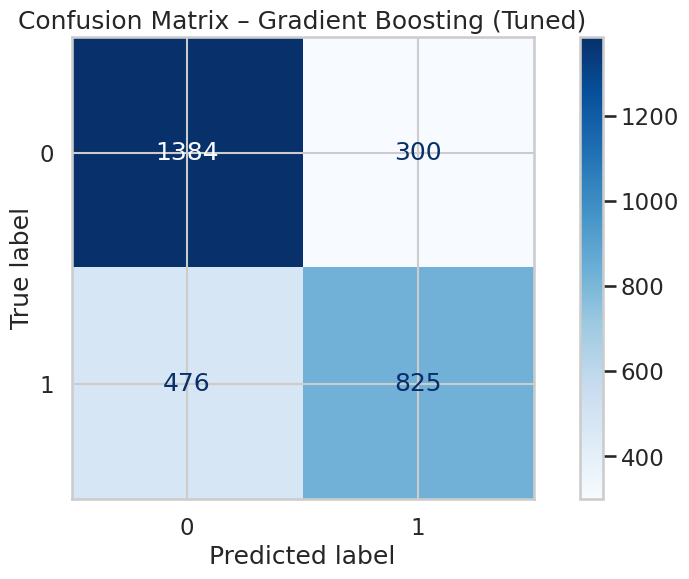

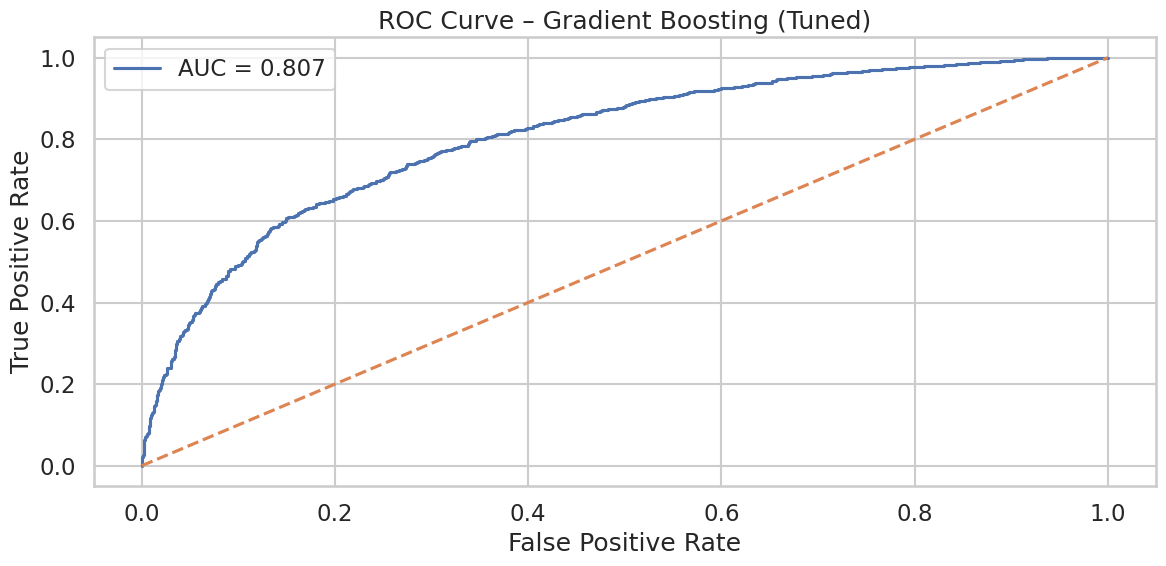

In [35]:
y_pred_test, y_proba_test = train_and_predict(best_gb_model, X_train, y_train, X_test)
classes = np.unique(y_train)

plot_confusion_matrix(y_test, y_pred_test, classes, "Confusion Matrix – Gradient Boosting (Tuned)")
plot_roc(y_test, y_proba_test, classes, "ROC Curve – Gradient Boosting (Tuned)")

cv_results = evaluate_cv(best_gb_model, X_train, y_train, cv)

gb_result = ModelResult(
    name="Gradient Boosting (Tuned)",
    cv_metrics=cv_results,
    y_pred_test=y_pred_test,
    y_proba_test=y_proba_test
)

tuned_parameters_results_list.append(gb_result)

### Model comparison after hyperparameters tuning

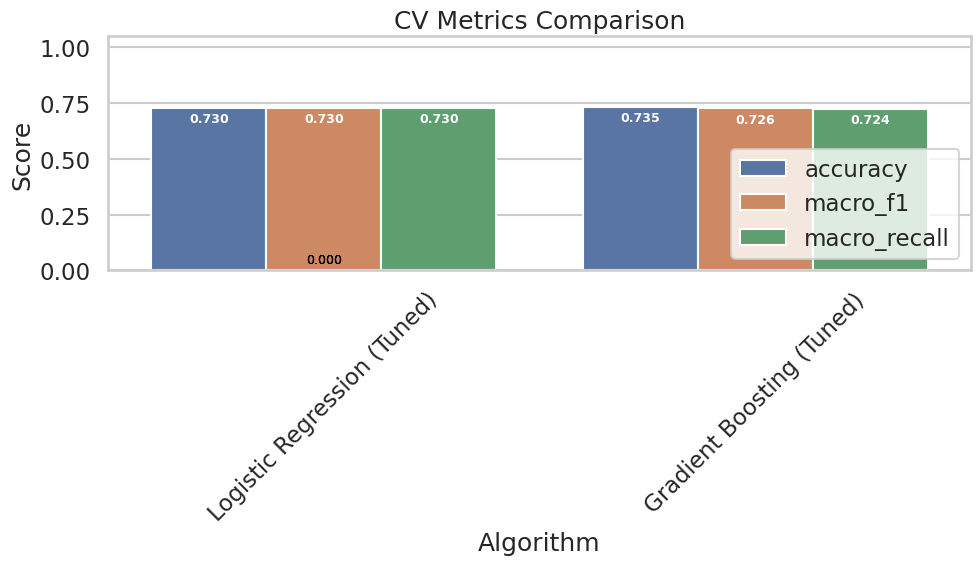

In [36]:
plot_cv_metrics(tuned_parameters_results_list)

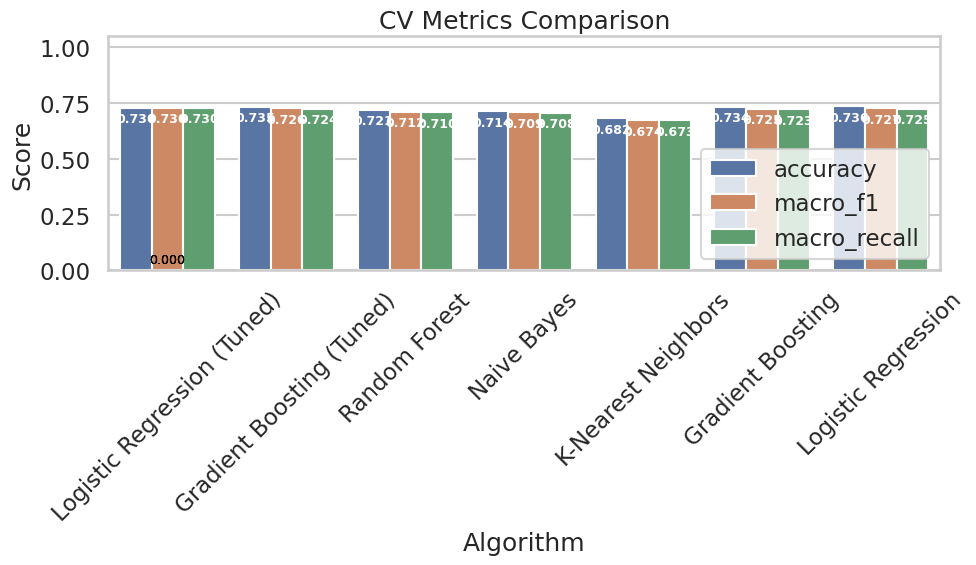

In [38]:
plot_cv_metrics(tuned_parameters_results_list + results_list)